In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

In [50]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
print(df.shape)

NUM_COLS = df.columns[1:-1]
df.head()

(2695, 22)


,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,0.202055,0.165019,0.399033,0.799019,5.426569,...,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,0.089377,0.220648,0.000000,0.933519,14.041958,...,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,0.235739,0.508929,0.888889,0.779049,5.017007,...,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,0.059439,0.030030,0.011111,0.942010,16.244444,...,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,0.135491,0.886686,0.489796,0.887341,10.558673,...,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


In [51]:
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
print(f"Shape: {df.shape}")

clf = IsolationForest(
    n_estimators=256,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination=0.05,       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df[NUM_COLS])

print(f"Number of outliers in df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

Shape: (2695, 22)
Number of outliers in df: 135


Винсоризация:

In [52]:

outliers_mask = (outliers_train == -1)

percentiles = {}
for col in NUM_COLS:
    p_low: float = df[col][outliers_mask != 1].min()
    p_high = df[col][outliers_mask != 1].max()
    percentiles[col] = (p_low, p_high)

df_clean: pd.DataFrame = df.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_clean.loc[outliers_mask, col] = col_data

    
#df_clean = df[outliers_mask != 1]
"""

df_clean = df.copy()
outliers_mask = (outliers_train == -1)

for col in NUM_COLS:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    # Применяем clip только к выбросам
    df_clean.loc[outliers_mask, col] = df_clean.loc[outliers_mask, col].clip(lower, upper)
"""

'\n\ndf_clean = df.copy()\noutliers_mask = (outliers_train == -1)\n\nfor col in NUM_COLS:\n    lower = df_clean[col].quantile(0.01)\n    upper = df_clean[col].quantile(0.99)\n    # Применяем clip только к выбросам\n    df_clean.loc[outliers_mask, col] = df_clean.loc[outliers_mask, col].clip(lower, upper)\n'

Стандартизация:

In [53]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

scaler.fit(df_clean)

df_array: np.ndarray = scaler.transform(df_clean)
df_stand: pd.DataFrame = pd.DataFrame(df_array,
                                             columns=df_clean.columns,
                                               index=df_clean.index)
df_stand.head()

,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,...,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,1.907025,-0.675745,-0.366427,-0.160390,-0.321278,-0.728808,-0.342690,1.007154,0.730890,-0.197103,...,-0.459226,-0.779117,-0.721057,-0.714123,-0.446798,0.356741,0.197595,-0.259591,-0.243582,-1.5
1,-0.377856,0.003808,0.091083,0.115689,0.941971,-1.297990,-0.081589,-0.780436,1.418055,1.040204,...,-0.388731,-0.707685,0.089138,-0.090392,-0.352455,0.069029,0.557174,-0.209387,-0.315155,-1.5
2,-0.433021,-1.047704,-0.492820,-0.847094,-2.480589,-0.558656,1.271497,3.201610,0.628864,-0.255922,...,-0.282988,-1.539686,-1.202126,-0.542951,2.034852,-0.072738,-5.851306,-0.735735,-0.513461,-1.5
3,-0.334818,3.851951,1.284178,1.890542,1.346100,-1.449216,-0.976280,-0.730660,1.461435,1.356516,...,-0.069809,2.289705,5.050281,0.947709,-0.571867,-0.074162,1.066070,4.463192,1.902120,-1.5
4,-0.411894,-0.127844,-0.484043,0.076928,0.786752,-1.065047,3.044553,1.413753,1.182127,0.539949,...,-0.610363,-1.040336,-0.566747,-0.777871,-0.566643,-0.080610,0.088524,-0.573443,-0.421925,-1.5


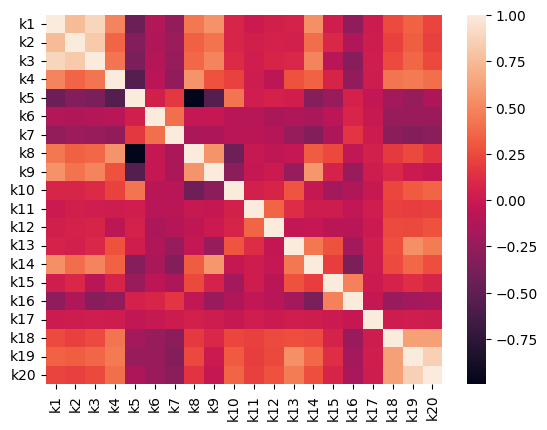

-0.9963776136177028


In [54]:
sns.heatmap(df_stand[NUM_COLS].corr())
plt.show()
print(df_stand[NUM_COLS].corr()['k5']['k8'])

In [55]:
df.drop('k8', axis=1, inplace=True)
NUM_COLS = df.columns[1:-1]

Метод главных компонент:

In [ ]:
from sklearn.decomposition import PCA

n_pca_components: int = 6
total_variance = np.sum(np.var(df_stand[NUM_COLS], axis=0, ddof=1))

pca = PCA(n_components=n_pca_components, random_state=42)
pca.fit(df_stand[NUM_COLS])
pca_eigen_values: np.ndarray = pca.explained_variance_

pca_res_df = pd.DataFrame(
    {"Eigen values": pca_eigen_values,
        "Explained variance ratio": pca.explained_variance_ratio_,
            "Cumsum of explained variance ratio": np.cumsum(pca.explained_variance_ratio_)},
    index=[i for i in range(n_pca_components)]
)
print(pca_res_df)

pca_array: np.ndarray = pca.transform(df_stand[NUM_COLS])
pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_pca: pd.DataFrame = pd.DataFrame(pca_array, columns=pca_columns, index=df_stand.index)
print("\nDataframe in principal components space:")
print(f"Shape: {df_pca.shape}")
print(df_pca.head())

[ 5.15911902e+00+0.00000000e+00j  2.73959613e+00+0.00000000e+00j
  1.72250736e+00+0.00000000e+00j ... -4.13134546e-19+9.31046118e-20j
 -4.13134546e-19-9.31046118e-20j -2.59656482e-20+0.00000000e+00j]
   Eigen values  Explained variance ratio  Cumsum of explained variance ratio
0      5.161034                  0.271533                            0.271533
1      2.740613                  0.144189                            0.415722
2      1.723147                  0.090658                            0.506380
3      1.413642                  0.074375                            0.580755
4      1.151165                  0.060565                            0.641320
5      1.130200                  0.059462                            0.700782

Dataframe in principal components space:
Shape: (2695, 6)
      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6
0 -1.077042  0.606572 -0.362563  0.292559 -0.657736  0.843046
1  0.898281  1.404652  0.416463  0.424126 -0.985419  0.467253
2 -5.4510

In [57]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(loadings_df[loadings_df >= 0.5])

          PC1       PC2       PC3       PC4       PC5       PC6
k1   0.781828       NaN       NaN       NaN       NaN       NaN
k2   0.685293       NaN       NaN       NaN       NaN       NaN
k3   0.771999       NaN       NaN       NaN       NaN       NaN
k4   0.681043       NaN       NaN       NaN       NaN       NaN
k5        NaN       NaN       NaN       NaN       NaN       NaN
k6        NaN       NaN       NaN       NaN       NaN  0.605752
k7        NaN       NaN       NaN       NaN       NaN       NaN
k9        NaN  0.672759       NaN       NaN       NaN       NaN
k10       NaN       NaN       NaN       NaN       NaN       NaN
k11       NaN       NaN       NaN  0.576396       NaN       NaN
k12       NaN       NaN       NaN  0.711492       NaN       NaN
k13       NaN       NaN       NaN       NaN       NaN       NaN
k14  0.688338       NaN       NaN       NaN       NaN       NaN
k15       NaN       NaN  0.865200       NaN       NaN       NaN
k16       NaN       NaN  0.595672       

In [58]:
from factor_analyzer import Rotator

rotator = Rotator(method='quartimax')
rotated_loadings = rotator.fit_transform(loadings)

rotated_eig_vals = np.sum(rotated_loadings**2, axis=0)      # сумма квадратов по строкам (признакам)

components = [f"PC{i+1}_rot" for i in range(len(rotated_eig_vals))]
df_eigen = pd.DataFrame({
    "Component": components,
    "Eigenvalue": rotated_eig_vals,
    "Variance %": (rotated_eig_vals / total_variance) * 100,
    "Cumulative %": np.cumsum(rotated_eig_vals / total_variance) * 100
})
print(df_eigen)

  Component  Eigenvalue  Variance %  Cumulative %
0   PC1_rot    3.556790   18.713000     18.713000
1   PC2_rot    3.456860   18.187248     36.900248
2   PC3_rot    1.554589    8.179012     45.079260
3   PC4_rot    1.481219    7.792998     52.872258
4   PC5_rot    1.879350    9.887644     62.759902
5   PC6_rot    1.390993    7.318297     70.078199


In [59]:
df_rotated_loadings = pd.DataFrame(
    rotated_loadings,
    columns=[f'PC{i+1}_rot' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)
print(df_rotated_loadings[df_rotated_loadings >= 0.4])

      PC1_rot  PC2_rot   PC3_rot   PC4_rot   PC5_rot   PC6_rot
k1   0.913694      NaN       NaN       NaN       NaN       NaN
k2   0.893764      NaN       NaN       NaN       NaN       NaN
k3   0.928877      NaN       NaN       NaN       NaN       NaN
k4   0.409786      NaN       NaN       NaN       NaN       NaN
k5        NaN      NaN       NaN       NaN  0.770048       NaN
k6        NaN      NaN       NaN       NaN       NaN  0.747251
k7        NaN      NaN       NaN       NaN       NaN  0.682727
k9   0.573470      NaN       NaN       NaN       NaN       NaN
k10       NaN      NaN       NaN       NaN  0.748899       NaN
k11       NaN      NaN       NaN  0.624025       NaN       NaN
k12       NaN      NaN       NaN  0.789628       NaN       NaN
k13       NaN      NaN       NaN       NaN       NaN       NaN
k14  0.445345      NaN       NaN       NaN       NaN       NaN
k15       NaN      NaN  0.804478       NaN       NaN       NaN
k16       NaN      NaN  0.862370       NaN       NaN   

In [60]:
# New PCA space
T = np.linalg.pinv(loadings) @ rotated_loadings
rot_pca_array = pca_array @ T
rot_pca_df: pd.DataFrame = pd.DataFrame(
    rot_pca_array,
    columns=[f"PCA{i+1}_rot" for i in range(pca.n_components_)], 
    index=df_stand.index
)
rot_pca_df.head()

,PCA1_rot,PCA2_rot,PCA3_rot,PCA4_rot,PCA5_rot,PCA6_rot
0,-0.800380,0.867773,-0.630018,0.149997,-0.677065,0.785403
1,0.711434,0.089922,-0.381333,-0.124729,-1.903768,-0.152077
2,-1.920054,5.070426,1.695752,-0.528821,0.259520,2.879669
3,5.184674,-5.451857,-0.122951,-1.601595,-1.912759,-2.262082
4,-0.049971,0.983423,-1.027448,-0.834476,-1.435114,3.410235


Добавление интегрального показателя:

In [61]:
integral_score = np.zeros(rot_pca_df.shape[0])
for i, col in enumerate(rot_pca_df.columns):
    integral_score += rot_pca_df[col] * (rotated_eig_vals[i] / total_variance)

#integral_score_normalized = 50 + (integral_score - integral_score.mean()) / integral_score.std() * 10
df_final = df_stand.copy()
df_final['int_score'] = integral_score

Количество найденных кластеров: 4
Количество точек, отнесённых к шуму: 0
Метки кластеров (первые 10): [2 2 1 0 1 0 2 0 2 2]

Число наблюдений в каждом кластере:
0 271
1 519
2 1377
3 528
Index(['PCA1_rot', 'PCA2_rot', 'PCA3_rot', 'PCA4_rot', 'PCA5_rot', 'PCA6_rot'], dtype='str')


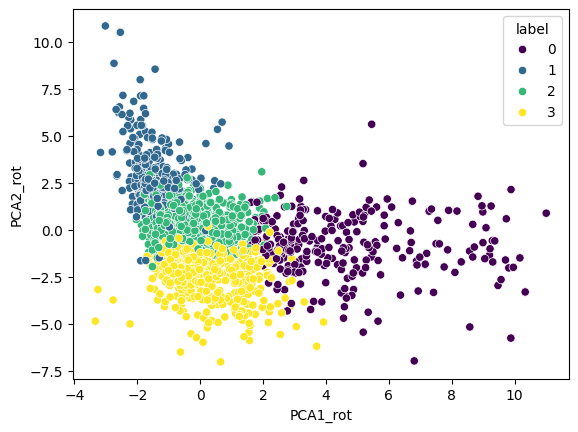

In [62]:
from sklearn.cluster import KMeans

#clusterer = HDBSCAN(min_cluster_size=5, copy=False)
clusterer = KMeans(n_clusters=4, random_state=42)
clusterer.fit(rot_pca_df)

# Результаты
labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 метка для шума
n_noise = list(labels).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество точек, отнесённых к шуму: {n_noise}")
print(f"Метки кластеров (первые 10): {labels[:10]}")
print("\nЧисло наблюдений в каждом кластере:")
#print(clusterer.probabilities_[:10])
for i in set(labels):
    print(i, np.sum(labels == i))

df_final['label'] = labels
print(rot_pca_df.columns)
#plt.scatter(df_pca['pca_1'], df_pca['pca_2'], с=labels, cmap='viridis')
sns.scatterplot(rot_pca_df, x='PCA1_rot', y='PCA2_rot', hue=df_final['label'], palette='viridis')
plt.show()

In [63]:
mean_int_per_label = df_final.groupby('label')['int_score'].mean()
mean_int_per_label

label
0    0.469459
1    0.342567
2   -0.084857
3   -0.356377
Name: int_score, dtype: float64

Переупорядочивание меток кластеров:

In [64]:
sorted_labels = mean_int_per_label.sort_values(ascending=False).index.tolist()
label_mapping = {old: new for new, old in enumerate(sorted_labels)}
df_final['label'] = df_final['label'].map(label_mapping)
df_final.groupby('label')['int_score'].mean()

label
0    0.469459
1    0.342567
2   -0.084857
3   -0.356377
Name: int_score, dtype: float64

In [65]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(df_final[NUM_COLS], df_final['label'], train_size=0.7)

In [66]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, solver='lbfgs', l1_ratio=0, max_iter=10000)
scores = cross_val_score(lr, X_train, y_train, cv=5)
scores

array([0.97883598, 0.9867374 , 0.98408488, 0.98143236, 0.98143236])

In [67]:
# Сетка для подбора C
param_grid = {
    'C': np.linspace(0.1, 100, 20) # от 0.001 до 100
}

# Поиск по сетке с кросс-валидацией
grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print(f"Лучшее значение C: {grid.best_params_['C']}")
print(f"Лучшая точность на кросс-валидации: {grid.best_score_:.4f}")

Лучшее значение C: 63.19473684210527
Лучшая точность на кросс-валидации: 0.9878


In [68]:
best_lr = grid.best_estimator_
best_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(63.19473684210527)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of pro

In [69]:
best_lr.coef_

array([[ 10.74505038,   8.32550307,   9.86665016,   4.2598793 ,
         -3.85169172,  -3.13930606,  -3.65458299,   9.86787066,
          0.7911193 ,   0.60728679,  -0.9201035 ,  -1.38720453,
          8.52391021,  -1.40691079,   1.60266258,  -0.79557515,
         -1.74842176,   8.78964053,   3.64781972],
       [ -4.96766672,  -4.78178593,  -7.66912303,  -7.79765655,
          3.62457787,   7.48014569,   8.87622012,  -4.77723766,
         -3.33897945,  -3.39518869,  -2.98916109,  -6.98661152,
        -11.18583358,  -0.07147495,   7.94484001,  -1.23664317,
         -7.59101116, -11.73721385, -11.04073325],
       [ -3.01938757,  -2.91909484,  -3.18738379,  -0.53998316,
          0.1096016 ,  -0.53050589,  -0.56650632,  -3.36564473,
         -1.91799967,  -0.98081341,  -0.36928948,   0.43507308,
          1.1532951 ,  -0.89694876,  -3.7591198 ,   0.77585136,
          0.57688365,  -4.1417253 ,  -1.77416505],
       [ -2.75799609,  -0.6246223 ,   0.98985666,   4.07776041,
          0.117

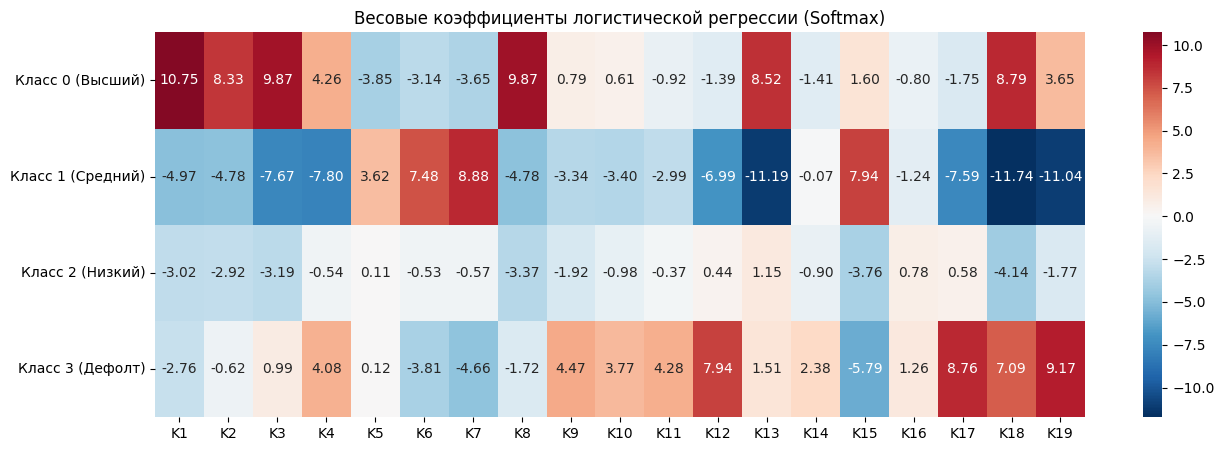

In [70]:
coef_matrix = best_lr.coef_
# coef_matrix - ваш массив 4x19
feature_names = [f'K{i+1}' for i in range(19)]
class_names = ['Класс 0 (Высший)', 'Класс 1 (Средний)', 'Класс 2 (Низкий)', 'Класс 3 (Дефолт)']

df_coef = pd.DataFrame(coef_matrix, index=class_names, columns=feature_names)

plt.figure(figsize=(15, 5))
sns.heatmap(df_coef, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Весовые коэффициенты логистической регрессии (Softmax)')
plt.show()

In [71]:
y_pred = best_lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
print(f"accuracy: {accuracy}, precision: {precision}, recall: {recall}, f1: {f1}")

accuracy: 0.9728059332509271, precision: 0.9682795787743701, recall: 0.9640689483162184, f1: 0.9660817927591204


In [72]:
confusion_matrix(y_test, y_pred)

array([[ 82,   0,   3,   2],
       [  0, 166,   4,   0],
       [  3,   3, 400,   0],
       [  3,   0,   4, 139]])